# Hindi Song Mood Classifier — Experiment Grid
### Comparing models × sampling strategies
**Models:** XGBoost, SVM, Logistic Regression, KNN, Random Forest  
**Strategies:** Baseline · Remove 'other' · Oversample (SMOTE) · Undersample · Remove+Oversample · Remove+Undersample  
**Total experiments:** 30 combinations


In [110]:
# Run once to install dependencies
# !pip install xgboost imbalanced-learn scikit-learn pandas matplotlib seaborn openpyxl


In [111]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import product

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
print("All imports OK")


All imports OK


In [112]:
# ── Load dataset ──────────────────────────────────────────────────────────
EXCEL_PATH = "3 moods with final mood_edited.xlsx"
TARGET_COL = "FINAL MOOD"

META_COLS = ["ID", "Song Title", "Film / Album", "Year",
             "ChatGPT Mood", "Claude Mood", "deepseek/copilot Mood",
             "FINAL MOOD", "Test", "File name"]

df = pd.read_excel(EXCEL_PATH)
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

print(f"Dataset shape   : {df.shape}")
print(f"Feature columns : {len(FEATURE_COLS)}")
print()
print("Class distribution:")
print(df[TARGET_COL].value_counts().to_string())


Dataset shape   : (1606, 61)
Feature columns : 51

Class distribution:
FINAL MOOD
romantic    398
other       345
sad         340
excited     325
happy       198


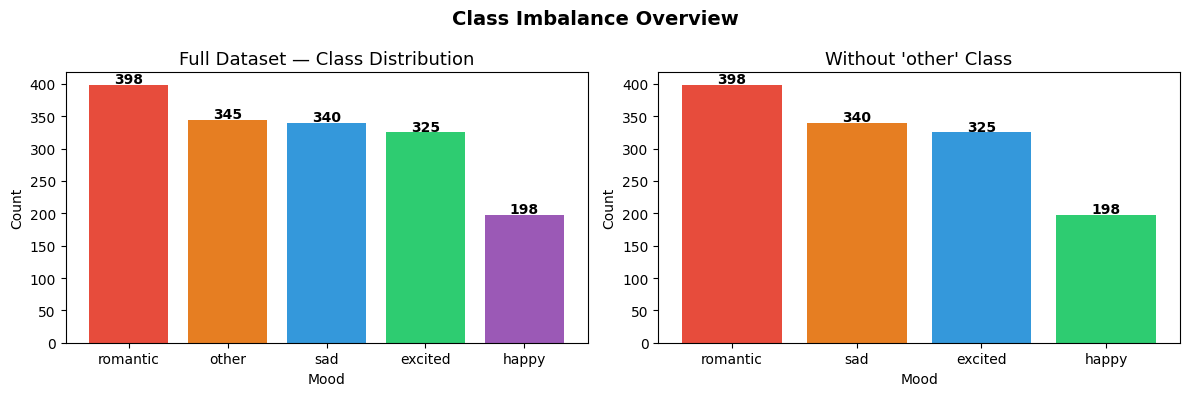

In [113]:
# ── Class distribution visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[TARGET_COL].value_counts()
colors = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71", "#9b59b6"]

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Full Dataset — Class Distribution", fontsize=13)
axes[0].set_xlabel("Mood"); axes[0].set_ylabel("Count")
for i, (cls, v) in enumerate(counts.items()):
    axes[0].text(i, v + 3, str(v), ha="center", fontsize=10, fontweight="bold")

counts_no_other = df.loc[df[TARGET_COL] != "other", TARGET_COL].value_counts()
axes[1].bar(counts_no_other.index, counts_no_other.values, color=colors[:4])
axes[1].set_title("Without 'other' Class", fontsize=13)
axes[1].set_xlabel("Mood"); axes[1].set_ylabel("Count")
for i, (cls, v) in enumerate(counts_no_other.items()):
    axes[1].text(i, v + 3, str(v), ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Class Imbalance Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [114]:
# ── Feature selection: drop low-variance + highly correlated ──────────────
from sklearn.preprocessing import MinMaxScaler

def drop_low_variance(X_df, threshold=0.01):
    scaled = pd.DataFrame(MinMaxScaler().fit_transform(X_df), columns=X_df.columns)
    return [c for c in scaled.columns if scaled[c].var() > threshold]

def drop_correlated(X_df, threshold=0.90):
    corr  = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop  = {c for c in upper.columns if any(upper[c] > threshold)}
    return [c for c in X_df.columns if c not in drop]

X_full = df[FEATURE_COLS].copy()
keep   = drop_low_variance(X_full)
X_full = X_full[keep]
keep   = drop_correlated(X_full)
X_full = X_full[keep]

print(f"Features after selection: {X_full.shape[1]}  (was {len(FEATURE_COLS)})")

y_full = df[TARGET_COL].values


Features after selection: 28  (was 51)


In [115]:
# ── Define models and sampling strategies ─────────────────────────────────

MODELS = {
    "Logistic (L1)": LogisticRegression(
        penalty="l1", solver="saga",
        max_iter=1000, class_weight="balanced",
        random_state=RANDOM_STATE),
    "Logistic (ElasticNet)": LogisticRegression(
        penalty="elasticnet", solver="saga",
        l1_ratio=0.5,
        max_iter=1000, class_weight="balanced",
        random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE),
    "LDA": LinearDiscriminantAnalysis(),

    "QDA": QuadraticDiscriminantAnalysis(),
}

STRATEGIES = [
    "baseline",
    "remove_other",
    "oversample",
    "undersample",
    "remove_other+oversample",
    "remove_other+undersample",
]

print(f"Models     : {list(MODELS.keys())}")
print(f"Strategies : {STRATEGIES}")
print(f"\nTotal experiments : {len(MODELS) * len(STRATEGIES)}")


Models     : ['Logistic (L1)', 'Logistic (ElasticNet)', 'Extra Trees', 'AdaBoost', 'LDA', 'QDA']
Strategies : ['baseline', 'remove_other', 'oversample', 'undersample', 'remove_other+oversample', 'remove_other+undersample']

Total experiments : 36


In [116]:
# ── Run all 30 experiments ────────────────────────────────────────────────

def prepare_data(strategy, X, y):
    """Apply sampling strategy and return (X_train, X_test, y_train, y_test, classes)."""
    remove_other = "remove_other" in strategy

    if remove_other:
        mask = y != "other"
        X_use, y_use = X[mask], y[mask]
    else:
        X_use, y_use = X.copy(), y.copy()

    le = LabelEncoder()
    y_enc = le.fit_transform(y_use)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_use.values, y_enc, test_size=0.2,
        stratify=y_enc, random_state=RANDOM_STATE)

    if "oversample" in strategy:
        sm = SMOTE(random_state=RANDOM_STATE)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
    elif "undersample" in strategy:
        rus = RandomUnderSampler(random_state=RANDOM_STATE)
        X_tr, y_tr = rus.fit_resample(X_tr, y_tr)

    return X_tr, X_te, y_tr, y_te, le


results = []  # list of dicts, one per experiment

for strategy in STRATEGIES:
    X_tr, X_te, y_tr, y_te, le = prepare_data(strategy, X_full, y_full)
    n_classes = len(le.classes_)

    print(f"\n{'='*60}")
    print(f"Strategy: {strategy.upper()}")
    print(f"  Train size: {len(X_tr)}  |  Test size: {len(X_te)}")
    print(f"  Classes: {list(le.classes_)}")
    tr_dist = pd.Series(y_tr).value_counts().to_dict()
    print(f"  Train dist: { {le.classes_[k]: v for k, v in tr_dist.items()} }")

    for model_name, clf in MODELS.items():
        # Wrap in scaling pipeline
        pipe = Pipeline([("sc", StandardScaler()), ("clf", clf)])

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        acc = accuracy_score(y_te, y_pred)
        f1  = f1_score(y_te, y_pred, average="macro")
        f1w = f1_score(y_te, y_pred, average="weighted")

        report = classification_report(
            y_te, y_pred, target_names=le.classes_, output_dict=True)

        results.append({
            "strategy"  : strategy,
            "model"     : model_name,
            "accuracy"  : acc,
            "f1_macro"  : f1,
            "f1_weighted": f1w,
            "report"    : report,
            "y_te"      : y_te,
            "y_pred"    : y_pred,
            "classes"   : list(le.classes_),
            "pipe"      : pipe,
        })

        print(f"  {model_name:<22}: Acc={acc:.4f}  F1-macro={f1:.4f}  F1-weighted={f1w:.4f}")

print("\n✅ All experiments complete.")



Strategy: BASELINE
  Train size: 1284  |  Test size: 322
  Classes: ['excited', 'happy', 'other', 'romantic', 'sad']
  Train dist: {'romantic': 318, 'other': 276, 'sad': 272, 'excited': 260, 'happy': 158}
  Logistic (L1)         : Acc=0.4348  F1-macro=0.4241  F1-weighted=0.4306
  Logistic (ElasticNet) : Acc=0.4441  F1-macro=0.4324  F1-weighted=0.4393
  Extra Trees           : Acc=0.4689  F1-macro=0.4259  F1-weighted=0.4473
  AdaBoost              : Acc=0.4161  F1-macro=0.3542  F1-weighted=0.3848
  LDA                   : Acc=0.4689  F1-macro=0.4200  F1-weighted=0.4485
  QDA                   : Acc=0.4037  F1-macro=0.3591  F1-weighted=0.3841

Strategy: REMOVE_OTHER
  Train size: 1008  |  Test size: 253
  Classes: ['excited', 'happy', 'romantic', 'sad']
  Train dist: {'romantic': 318, 'sad': 272, 'excited': 260, 'happy': 158}
  Logistic (L1)         : Acc=0.5810  F1-macro=0.5550  F1-weighted=0.5789
  Logistic (ElasticNet) : Acc=0.5771  F1-macro=0.5494  F1-weighted=0.5757
  Extra Trees  

In [117]:
# ── Summary table: all 30 experiments ────────────────────────────────────
summary = pd.DataFrame([{
    "Strategy"   : r["strategy"],
    "Model"      : r["model"],
    "Accuracy"   : round(r["accuracy"],  4),
    "F1-macro"   : round(r["f1_macro"],  4),
    "F1-weighted": round(r["f1_weighted"],4),
} for r in results])

# Highlight best F1-macro per strategy
def highlight_best(s):
    is_max = s == s.max()
    return ["background-color: #d4edda; font-weight: bold" if v else "" for v in is_max]

display(
    summary.style
    .apply(highlight_best, subset=["F1-macro"], axis=0)
    .format({"Accuracy": "{:.4f}", "F1-macro": "{:.4f}", "F1-weighted": "{:.4f}"})
    .set_caption("All Experiments — Green = best F1-macro per strategy")
)


,Strategy,Model,Accuracy,F1-macro,F1-weighted
0,baseline,Logistic (L1),0.4348,0.4241,0.4306
1,baseline,Logistic (ElasticNet),0.4441,0.4324,0.4393
2,baseline,Extra Trees,0.4689,0.4259,0.4473
3,baseline,AdaBoost,0.4161,0.3542,0.3848
4,baseline,LDA,0.4689,0.4200,0.4485
5,baseline,QDA,0.4037,0.3591,0.3841
6,remove_other,Logistic (L1),0.5810,0.5550,0.5789
7,remove_other,Logistic (ElasticNet),0.5771,0.5494,0.5757
8,remove_other,Extra Trees,0.5810,0.4975,0.5419
9,remove_other,AdaBoost,0.4980,0.4067,0.4509


In [118]:
# ── Best model per strategy ───────────────────────────────────────────────
best_per_strategy = (
    summary.sort_values("F1-macro", ascending=False)
           .groupby("Strategy").first()
           .reset_index()
           [["Strategy", "Model", "Accuracy", "F1-macro", "F1-weighted"]]
           .sort_values("F1-macro", ascending=False)
)

print("Best model per strategy (sorted by F1-macro):")
display(best_per_strategy.style.format({
    "Accuracy": "{:.4f}", "F1-macro": "{:.4f}", "F1-weighted": "{:.4f}"}))


Best model per strategy (sorted by F1-macro):


,Strategy,Model,Accuracy,F1-macro,F1-weighted
2,remove_other,Logistic (L1),0.5810,0.5550,0.5789
4,remove_other+undersample,Extra Trees,0.5771,0.5473,0.5615
3,remove_other+oversample,LDA,0.5573,0.5338,0.5592
1,oversample,Extra Trees,0.4814,0.4630,0.4714
5,undersample,LDA,0.4441,0.4352,0.4443
0,baseline,Logistic (ElasticNet),0.4441,0.4324,0.4393


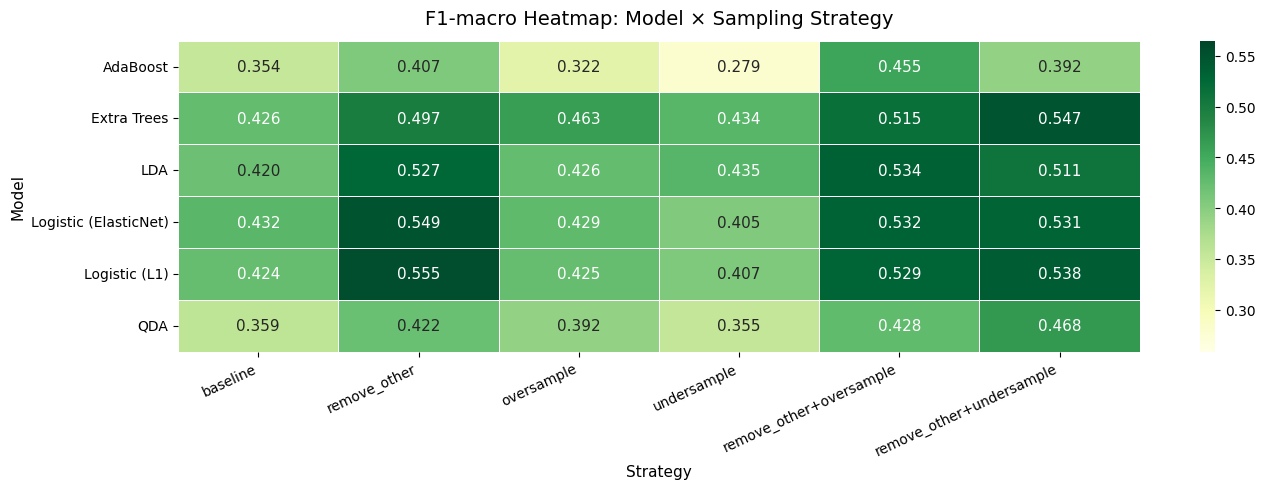

In [119]:
# ── Heatmap: F1-macro for all model × strategy combinations ───────────────
pivot = summary.pivot(index="Model", columns="Strategy", values="F1-macro")
# Order strategies sensibly
col_order = [c for c in STRATEGIES if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 11}, ax=ax,
            vmin=pivot.values.min() - 0.02,
            vmax=pivot.values.max() + 0.01)
ax.set_title("F1-macro Heatmap: Model × Sampling Strategy", fontsize=14, pad=12)
ax.set_xlabel("Strategy", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


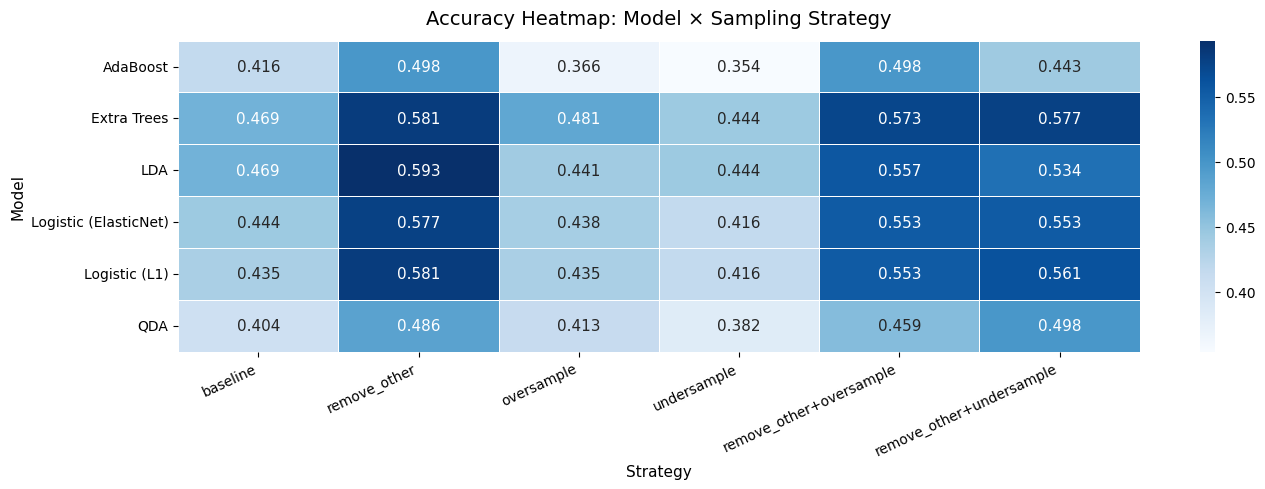

In [120]:
# ── Heatmap: Accuracy ─────────────────────────────────────────────────────
pivot_acc = summary.pivot(index="Model", columns="Strategy", values="Accuracy")[col_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 11}, ax=ax)
ax.set_title("Accuracy Heatmap: Model × Sampling Strategy", fontsize=14, pad=12)
ax.set_xlabel("Strategy", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


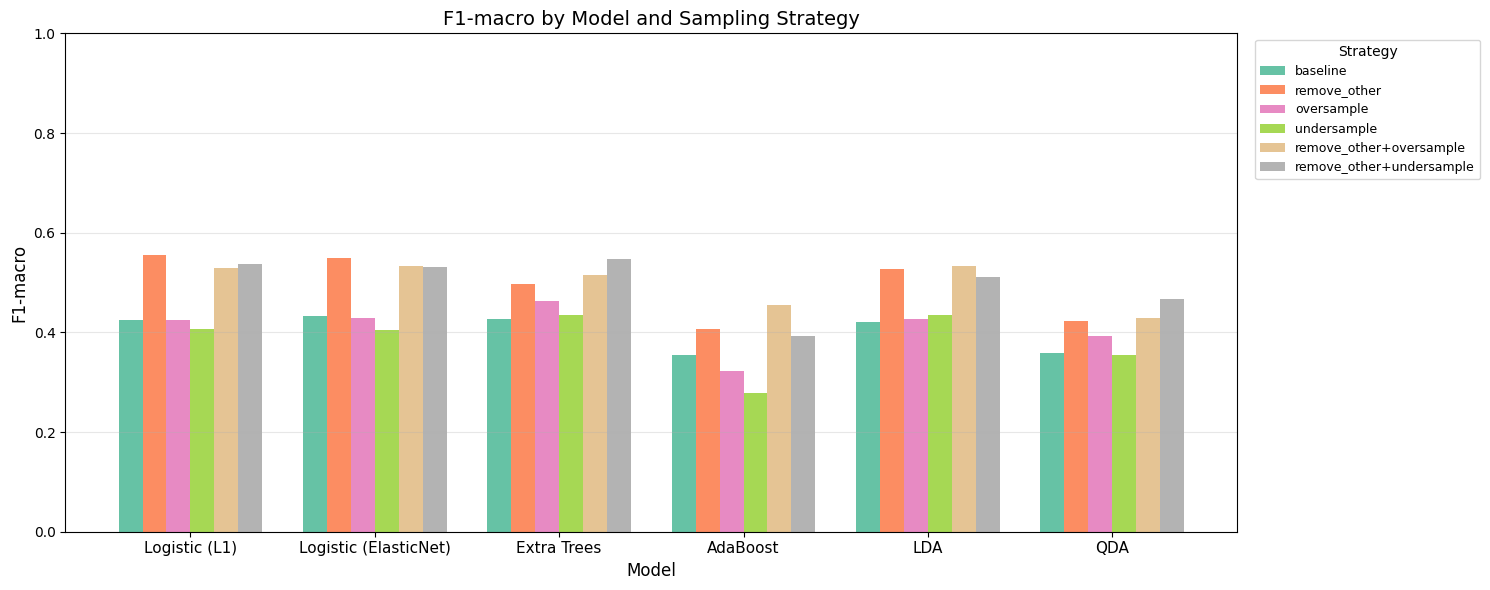

In [121]:
# ── Grouped bar: F1-macro per model across strategies ─────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
model_names = list(MODELS.keys())
x = np.arange(len(model_names))
n_strat = len(STRATEGIES)
width = 0.13
colors_strat = plt.cm.Set2(np.linspace(0, 1, n_strat))

for i, strat in enumerate(STRATEGIES):
    vals = [summary.loc[(summary.Model == m) & (summary.Strategy == strat),
                        "F1-macro"].values[0] for m in model_names]
    offset = (i - n_strat / 2) * width + width / 2
    bars = ax.bar(x + offset, vals, width, label=strat, color=colors_strat[i])

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("F1-macro", fontsize=12)
ax.set_title("F1-macro by Model and Sampling Strategy", fontsize=14)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(title="Strategy", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


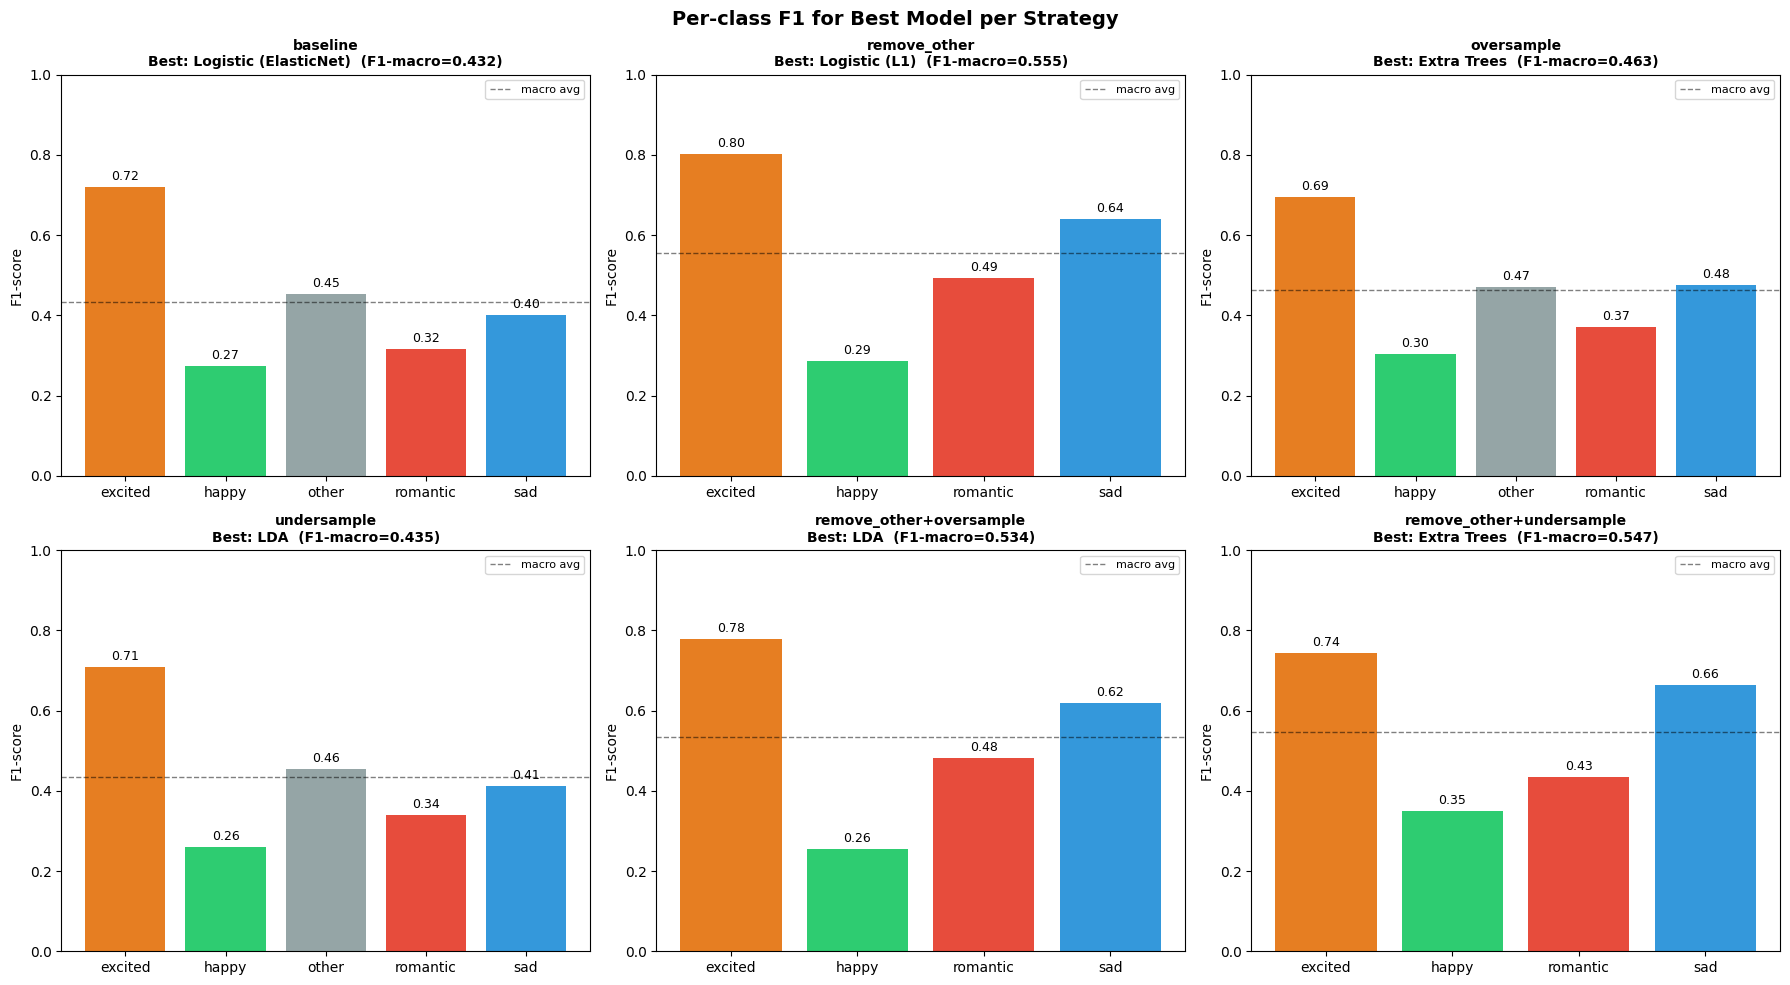

In [122]:
# ── Per-class F1 breakdown for best experiment per strategy ───────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax_idx, strat in enumerate(STRATEGIES):
    # Find best model for this strategy
    strat_results = [r for r in results if r["strategy"] == strat]
    best = max(strat_results, key=lambda r: r["f1_macro"])
    classes = best["classes"]
    report  = best["report"]

    class_f1 = {cls: report[cls]["f1-score"] for cls in classes}
    mood_colors = {
        "happy":    "#2ecc71",
        "sad":      "#3498db",
        "romantic": "#e74c3c",
        "excited":  "#e67e22",
        "other":    "#95a5a6",
    }
    bar_colors = [mood_colors.get(c, "#7f8c8d") for c in class_f1]

    bars = axes[ax_idx].bar(class_f1.keys(), class_f1.values(), color=bar_colors)
    axes[ax_idx].set_title(
        f"{strat}\nBest: {best['model']}  (F1-macro={best['f1_macro']:.3f})",
        fontsize=10, fontweight="bold")
    axes[ax_idx].set_ylim(0, 1)
    axes[ax_idx].set_ylabel("F1-score")
    axes[ax_idx].axhline(best["f1_macro"], color="black",
                          linestyle="--", linewidth=1, alpha=0.5, label="macro avg")
    axes[ax_idx].legend(fontsize=8)
    for bar, (cls, val) in zip(bars, class_f1.items()):
        axes[ax_idx].text(bar.get_x() + bar.get_width()/2,
                           val + 0.01, f"{val:.2f}",
                           ha="center", va="bottom", fontsize=9)

plt.suptitle("Per-class F1 for Best Model per Strategy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


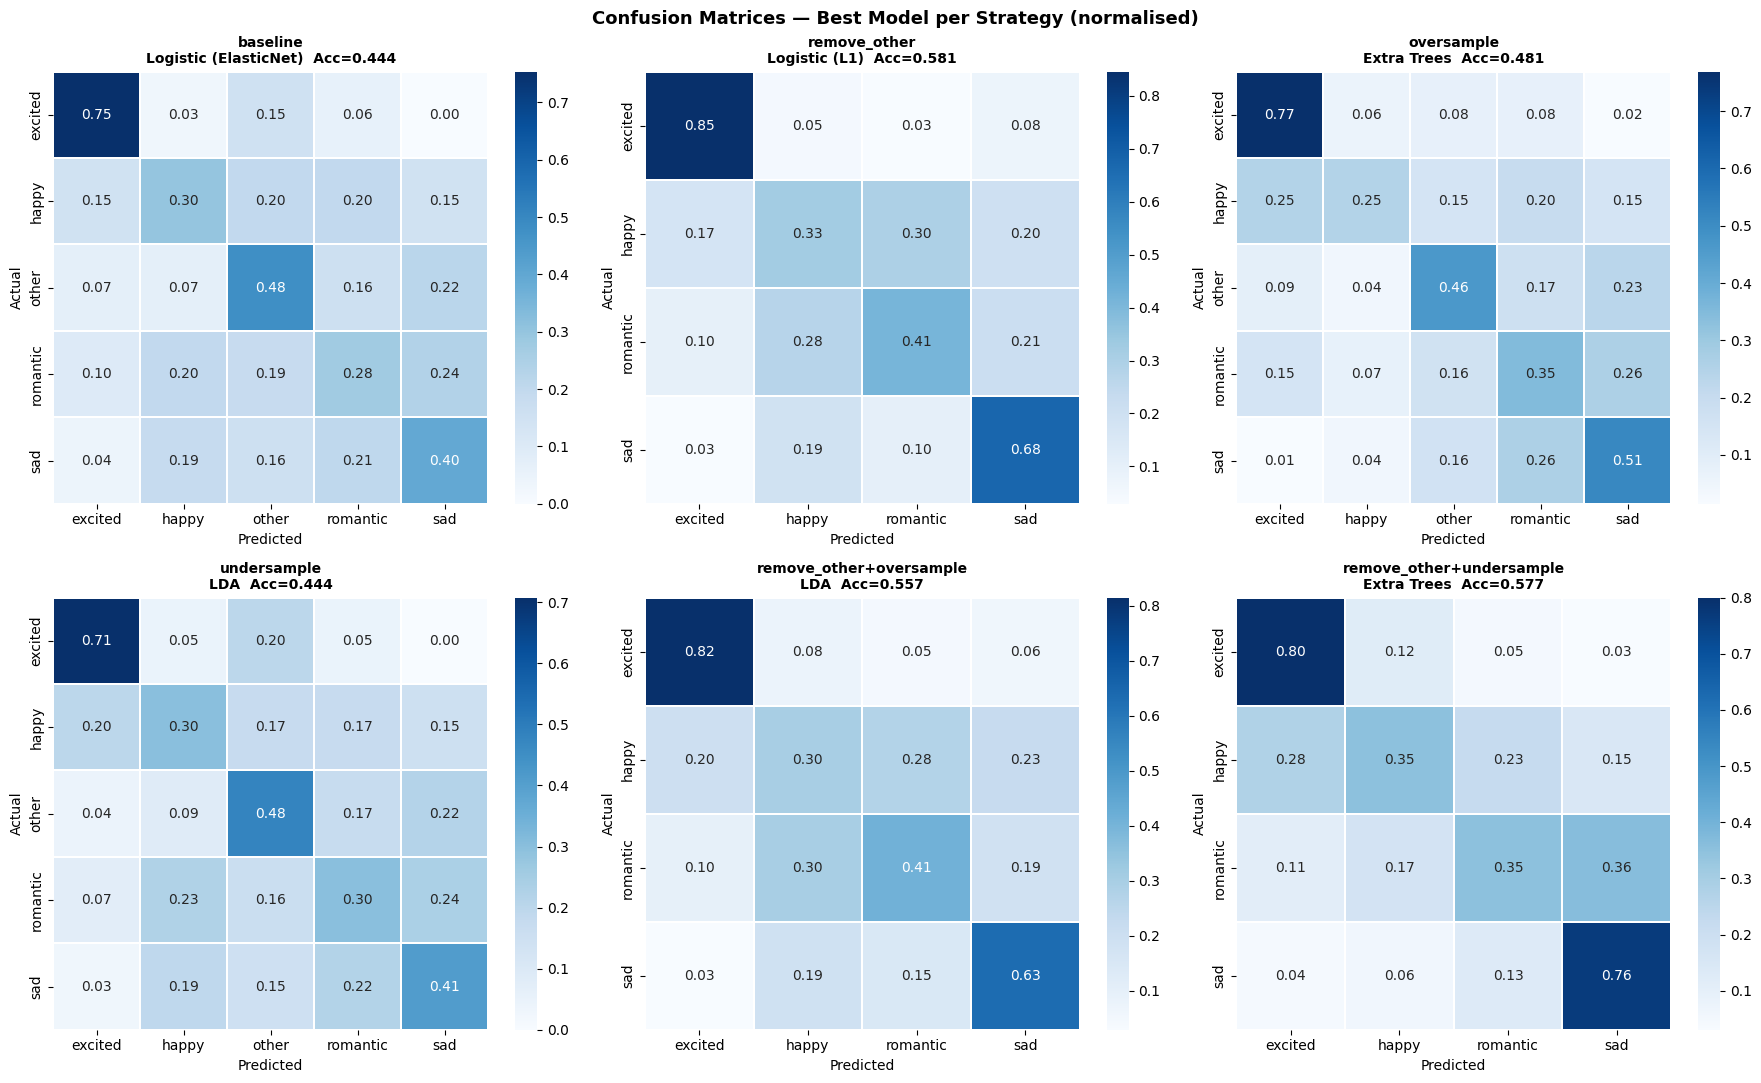

In [123]:
# ── Confusion matrices for best model per strategy ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax_idx, strat in enumerate(STRATEGIES):
    strat_results = [r for r in results if r["strategy"] == strat]
    best = max(strat_results, key=lambda r: r["f1_macro"])

    cm   = confusion_matrix(best["y_te"], best["y_pred"])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=best["classes"], yticklabels=best["classes"],
                ax=axes[ax_idx], linewidths=0.3)
    axes[ax_idx].set_title(
        f"{strat}\n{best['model']}  Acc={best['accuracy']:.3f}",
        fontsize=10, fontweight="bold")
    axes[ax_idx].set_xlabel("Predicted"); axes[ax_idx].set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Best Model per Strategy (normalised)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [124]:
# ── Full classification reports for every experiment ─────────────────────
for strat in STRATEGIES:
    print("\n" + "="*70)
    print(f"  STRATEGY: {strat.upper()}")
    print("="*70)
    for r in [x for x in results if x["strategy"] == strat]:
        print(f"\n--- {r['model']} ---")
        print(f"  Accuracy   : {r['accuracy']:.4f}")
        print(f"  F1-macro   : {r['f1_macro']:.4f}")
        print(f"  F1-weighted: {r['f1_weighted']:.4f}")
        rpt = r["report"]
        header = f"{'Class':<14} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}"
        print("  " + header)
        print("  " + "-"*len(header))
        for cls in r["classes"]:
            row = rpt[cls]
            print(f"  {cls:<14} {row['precision']:>10.4f} {row['recall']:>10.4f} "
                  f"{row['f1-score']:>10.4f} {int(row['support']):>10}")
        print(f"  {'macro avg':<14} {rpt['macro avg']['precision']:>10.4f} "
              f"{rpt['macro avg']['recall']:>10.4f} "
              f"{rpt['macro avg']['f1-score']:>10.4f} "
              f"{int(rpt['macro avg']['support']):>10}")



  STRATEGY: BASELINE

--- Logistic (L1) ---
  Accuracy   : 0.4348
  F1-macro   : 0.4241
  F1-weighted: 0.4306
  Class           Precision     Recall         F1    Support
  ----------------------------------------------------------
  excited            0.6901     0.7538     0.7206         65
  happy              0.2449     0.3000     0.2697         40
  other              0.4267     0.4638     0.4444         69
  romantic           0.3548     0.2750     0.3099         80
  sad                0.3846     0.3676     0.3759         68
  macro avg          0.4202     0.4321     0.4241        322

--- Logistic (ElasticNet) ---
  Accuracy   : 0.4441
  F1-macro   : 0.4324
  F1-weighted: 0.4393
  Class           Precision     Recall         F1    Support
  ----------------------------------------------------------
  excited            0.6901     0.7538     0.7206         65
  happy              0.2500     0.3000     0.2727         40
  other              0.4286     0.4783     0.4521         69

In [125]:
# ── Overall leaderboard: top 10 experiments ──────────────────────────────
leaderboard = summary.sort_values("F1-macro", ascending=False).head(10).reset_index(drop=True)
leaderboard.index += 1
print("Top 10 experiments overall:")
display(leaderboard.style
    .format({"Accuracy": "{:.4f}", "F1-macro": "{:.4f}", "F1-weighted": "{:.4f}"})
    .bar(subset=["F1-macro"], color="#2ecc71", vmin=0, vmax=1)
    .set_caption("Top 10 — sorted by F1-macro"))


Top 10 experiments overall:


,Strategy,Model,Accuracy,F1-macro,F1-weighted
1,remove_other,Logistic (L1),0.5810,0.5550,0.5789
2,remove_other,Logistic (ElasticNet),0.5771,0.5494,0.5757
3,remove_other+undersample,Extra Trees,0.5771,0.5473,0.5615
4,remove_other+undersample,Logistic (L1),0.5613,0.5376,0.5634
5,remove_other+oversample,LDA,0.5573,0.5338,0.5592
6,remove_other+oversample,Logistic (ElasticNet),0.5534,0.5323,0.5556
7,remove_other+undersample,Logistic (ElasticNet),0.5534,0.5313,0.5569
8,remove_other+oversample,Logistic (L1),0.5534,0.5295,0.5551
9,remove_other,LDA,0.5929,0.5272,0.5668
10,remove_other+oversample,Extra Trees,0.5731,0.5152,0.5503


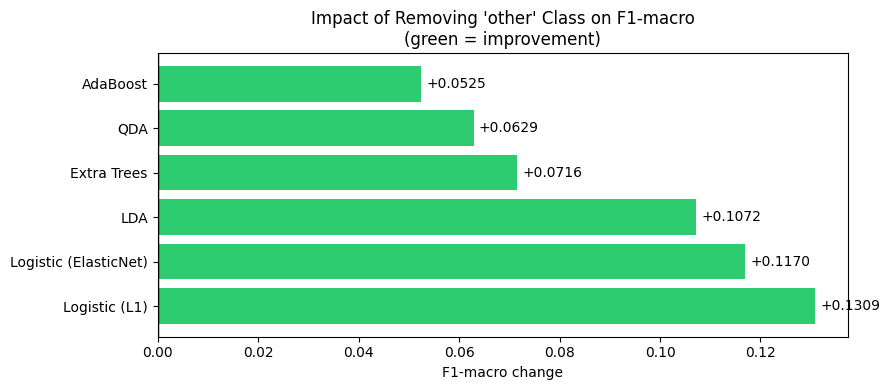


Delta F1-macro (remove_other - baseline):
Model
Logistic (L1)           0.1309
Logistic (ElasticNet)   0.1170
LDA                     0.1072
Extra Trees             0.0716
QDA                     0.0629
AdaBoost                0.0525


In [126]:
# ── Impact analysis: removing 'other' class ──────────────────────────────
baseline_f1    = summary[summary.Strategy == "baseline"].set_index("Model")["F1-macro"]
no_other_f1    = summary[summary.Strategy == "remove_other"].set_index("Model")["F1-macro"]
delta = (no_other_f1 - baseline_f1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in delta.values]
ax.barh(delta.index, delta.values, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("F1-macro change")
ax.set_title("Impact of Removing 'other' Class on F1-macro\n(green = improvement)")
for i, v in enumerate(delta.values):
    ax.text(v + (0.001 if v >= 0 else -0.001), i,
            f"{v:+.4f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=10)
plt.tight_layout()
plt.show()

print("\nDelta F1-macro (remove_other - baseline):")
print(delta.to_string())


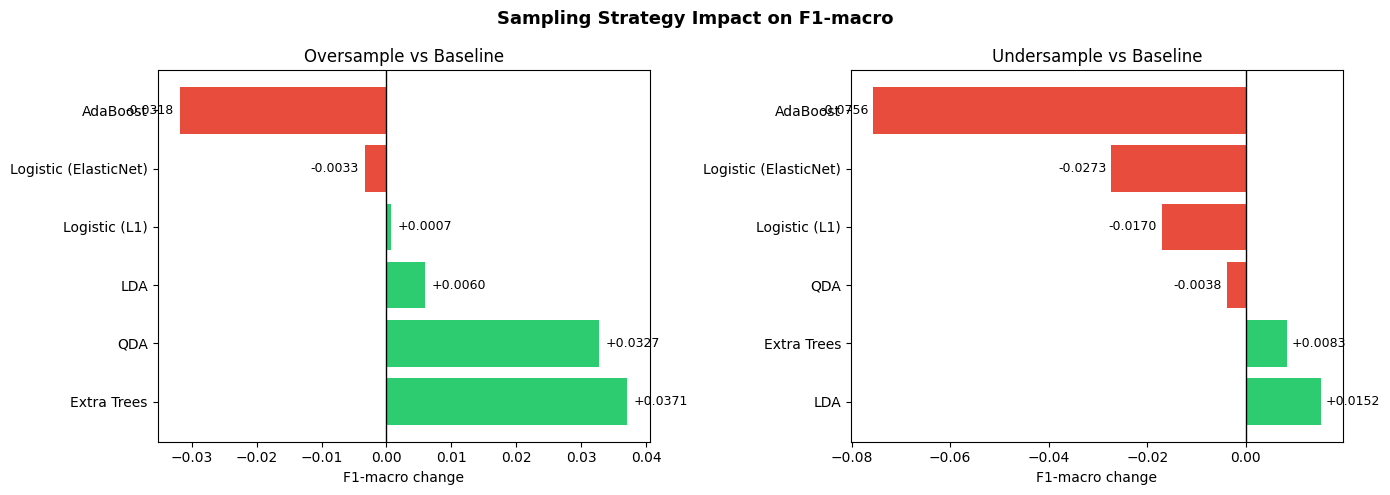

In [127]:
# ── Impact analysis: sampling strategies vs baseline ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ref_strat, compare_strat, title in [
    (axes[0], "baseline",     "oversample",  "Oversample vs Baseline"),
    (axes[1], "baseline",     "undersample", "Undersample vs Baseline"),
]:
    ref  = summary[summary.Strategy == ref_strat].set_index("Model")["F1-macro"]
    comp = summary[summary.Strategy == compare_strat].set_index("Model")["F1-macro"]
    delta = (comp - ref).sort_values(ascending=False)
    colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in delta.values]
    ax.barh(delta.index, delta.values, color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("F1-macro change")
    ax.set_title(title)
    for i, v in enumerate(delta.values):
        ax.text(v + (0.001 if v >= 0 else -0.001), i,
                f"{v:+.4f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=9)

plt.suptitle("Sampling Strategy Impact on F1-macro", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [128]:
# ── Save summary to CSV ───────────────────────────────────────────────────
summary.to_csv("experiment_results.csv", index=False)
print("Saved to experiment_results.csv")
print()
print("Final summary:")
display(summary.sort_values(["Strategy", "F1-macro"], ascending=[True, False]))


Saved to experiment_results.csv

Final summary:


,Strategy,Model,Accuracy,F1-macro,F1-weighted
1,baseline,Logistic (ElasticNet),0.4441,0.4324,0.4393
2,baseline,Extra Trees,0.4689,0.4259,0.4473
0,baseline,Logistic (L1),0.4348,0.4241,0.4306
4,baseline,LDA,0.4689,0.4200,0.4485
5,baseline,QDA,0.4037,0.3591,0.3841
3,baseline,AdaBoost,0.4161,0.3542,0.3848
14,oversample,Extra Trees,0.4814,0.4630,0.4714
13,oversample,Logistic (ElasticNet),0.4379,0.4291,0.4356
16,oversample,LDA,0.4410,0.4260,0.4400
12,oversample,Logistic (L1),0.4348,0.4248,0.4325
